# Prueba técnica Sudata
Autor: Patricio García <br>
Correo: patricionerigacia@gmail.com

## Parte 2 - Modelado
En esta sección se realiza el modelado y evalución de modelos de Machine Learning para la predicción de precios de viviendas.

### Librerias

In [108]:
# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn - model selection
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV

# Scikit-learn - preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn - modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Scikit-learn - pipeline
from sklearn.pipeline import Pipeline

# Scikit-learn - métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer


### Carga de datos

In [109]:
# Carga el dataset unificado
df = pd.read_csv("../data/dataset_unificado.csv")
df.head()

,source,price,total_area_m2,covered_area_m2,rooms,bedrooms,bathrooms,property_type,neighborhood,lat,lon,bedrooms_missing,bathrooms_missing,rooms_missing
0,A,584.0,39.0,39.0,2.0,1.0,1.0,departamento,almagro,-34.608738,-58.439099,0,1,0
1,A,252.0,35.0,35.0,2.0,1.0,1.0,departamento,flores,-34.622051,-58.456267,1,0,0
2,A,546.0,38.0,38.0,2.0,1.0,1.0,ph,belgrano,-34.574757,-58.463758,0,0,0
3,A,337.0,33.0,33.0,1.0,1.0,1.0,departamento,villa urquiza,-34.554289,-58.486616,1,0,0
4,A,774.0,76.0,76.0,3.0,2.0,1.0,departamento,boedo,-34.623449,-58.408106,0,1,0


### Definiciones

In [110]:
# Define target y features
target = "price"

features = [
    "total_area_m2",
    "covered_area_m2",
    "rooms",
    "bedrooms",
    "bathrooms",
    "property_type",
    "neighborhood",
    "lat",
    "lon",
    #"source"
]

X = df[features]
y = df[target]

In [111]:
# Divide en train y validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [112]:
# Define variables numéricas y categóricas
numeric_features = [
    "total_area_m2",
    "covered_area_m2",
    "rooms",
    "bedrooms",
    "bathrooms",
    "lat",
    "lon"
]

categorical_features = [
    "property_type",
    "neighborhood",
    # "source"
]


# Preprocesamiento: estandarización para numéricas y one-hot encoding para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### Regresión lineal

In [113]:
# Define pipeline con preprocesamiento y modelo
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [114]:
# Entrena el modelo
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [115]:
# Evaluación con cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

In [116]:
# Resumen de resultados
cv_summary = pd.DataFrame({
    "metric": ["R2", "RMSE", "MAE"],
    "train_mean": [
        cv_results["train_r2"].mean(),
        -cv_results["train_rmse"].mean(),
        -cv_results["train_mae"].mean()
    ],
    "validation_mean": [
        cv_results["test_r2"].mean(),
        -cv_results["test_rmse"].mean(),
        -cv_results["test_mae"].mean()
    ],
    "validation_std": [
        cv_results["test_r2"].std(),
        cv_results["test_rmse"].std(),
        cv_results["test_mae"].std()
    ]
}).round(2)

cv_summary

,metric,train_mean,validation_mean,validation_std
0,R2,0.66,0.65,0.02
1,RMSE,422738.03,427268.06,14902.54
2,MAE,327582.83,330163.34,8409.06


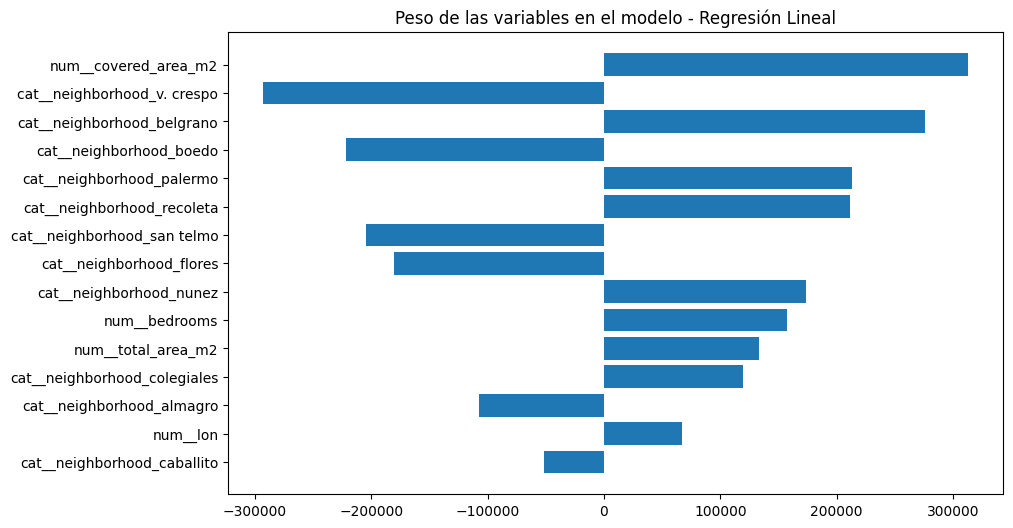

In [117]:
# Análisis de importancia de variables
linear_model = model.named_steps["model"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coef", ascending=False)



top_features = coef_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.gca().invert_yaxis()
plt.title("Peso de las variables en el modelo - Regresión Lineal")
plt.show()

### Random Forest

In [118]:
# Define pipeline con preprocesamiento y modelo de Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [119]:
# Grilla de hiperparámetros para Random Forest
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"]
}

In [120]:
# Búsqueda de hiperparámetros con GridSearchCV
grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 3, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [121]:
# Mejor combinación de hiperparámetros
grid.best_params_


{'model__max_depth': 20,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200}

In [122]:
# Modelo final con los mejores hiperparámetros
best_model = grid.best_estimator_

In [123]:
# Evaluación del modelo final con cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True
)

In [124]:
# Resumen de resultados
results_df = pd.DataFrame({
    "metric": ["R2", "RMSE", "MAE"],
    "train_mean": [
        cv_results["train_r2"].mean(),
        -cv_results["train_rmse"].mean(),
        -cv_results["train_mae"].mean()
    ],
    "validation_mean": [
        cv_results["test_r2"].mean(),
        -cv_results["test_rmse"].mean(),
        -cv_results["test_mae"].mean()
    ],
    "validation_std": [
        cv_results["test_r2"].std(),
        cv_results["test_rmse"].std(),
        cv_results["test_mae"].std()
    ]
}).round(2)

results_df

,metric,train_mean,validation_mean,validation_std
0,R2,0.94,0.68,0.02
1,RMSE,174055.55,407359.86,21218.42
2,MAE,139376.39,319194.89,6721.13


### Proximos pasos
- Aumentar registros en dataset
- Modificar outliers
- Transformaciones (por ejemplo, logaritmica a variable target)
- Feature engineering

In [125]:
# Feature engineering: nuevas variables basadas en las existentes
df["price_m2"] = df["price"] / df["total_area_m2"]
df["ratio_covered"] = df["covered_area_m2"] / df["total_area_m2"]
df["rooms_density"] = df["rooms"] / df["total_area_m2"]